# RQ1 factor B - retrieval strategy

**What varies:** how candidate segments are scored, four levels.
**What is held constant:** 512-unit sliding-window segments with 10% overlap, no reranking,
candidate depth 20, context depth 5, all 910 questions.

**The centre point.** Every notebook varies one factor and holds the rest at 512-unit sliding
window segments with 10% overlap, BGE-small dense retrieval, no reranking, candidate depth 20
and context depth 5. That is what makes each measurement a *main effect*: no arm differs from
the centre in two ways at once.

**Levels**

| Level | Scoring |
|---|---|
| BM25 | k1 = 1.5, b = 0.75, non-negative IDF, corpus-wide document frequencies |
| dense *(centre point)* | BGE-small cosine similarity |
| hybrid RRF | reciprocal rank fusion of the two lists, k = 60 |
| hybrid weighted | 0.5 x z-scored dense + 0.5 x z-scored BM25 |

Because the two hybrids are built from exactly the same BM25 and dense lists, any difference
between them is the fusion rule alone.

**Runtime:** about 6 minutes, most of it building the BM25 index once.

## 1. Open the shared cache

In [1]:
# Load the shared library written by notebook 00 and open the same cache.
import sys, os
from google.colab import drive
drive.mount('/content/drive')
PROJECT = '/content/drive/MyDrive/techqa_rq1'
assert os.path.exists(PROJECT + '/rq1_core.py'), (
    'rq1_core.py not found. Run RQ1_00_Build_Once.ipynb first - it writes the library '
    'and builds the chunk tables and embeddings that this notebook reads from cache.')
sys.path.insert(0, PROJECT)
import rq1_core as C
import numpy as np, pandas as pd, time, json
C.setup(project_dir=PROJECT)
print('GPU:', C.gpu_name())

Mounted at /content/drive
rq1_core 1.0 | profile=fast | run tag u512_o10_p0
  cache   -> /content/drive/MyDrive/techqa_rq1/cache_u512_o10_p0
  outputs -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0
GPU: Tesla T4


In [2]:
# The whole labelled dataset, on the fast local disk.
# Notebook 00 mirrors the four extracted files to Drive, so this fresh runtime restores them
# with a file copy (~1 min) instead of re-downloading and re-extracting the archive (~5 min).
if not C.dataset_present():
    if C.dataset_mirrored():
        print('restoring the corpus from the Drive mirror ...')
        C.restore_dataset_from_mirror()
    else:
        dl, ex = C.download_commands()
        get_ipython().system(dl)
        get_ipython().system(ex)
        C.mirror_dataset()
ds = C.load_dataset()
print(json.dumps(ds.summary(), indent=1))

restoring the corpus from the Drive mirror ...
{
 "questions": 910,
 "answerable": 610,
 "unanswerable": 300,
 "per_split": {
  "train": [
   600,
   450
  ],
  "dev": [
   310,
   160
  ]
 },
 "technotes": 28482,
 "candidate_technotes": 28461
}


## 2. Every retrieval strategy at the centre-point segmentation

In [3]:
idx = C.load_method_index(ds, C.CFG.BASELINE_METHOD, with_bm25=True)
print(f"{len(idx.table):,} chunks | BM25 index built in "
      f"{idx.timings['bm25_index_s']:.0f}s, {idx.bm25.memory_mb():.0f} MB, "
      f"{len(idx.bm25.vocab):,} terms")

38,046 chunks | BM25 index built in 10s, 48 MB, 368,938 terms


In [4]:
frames, contexts, cost = [], {}, []
for r in C.CFG.RETRIEVERS:
    t0 = time.perf_counter()
    df, latency = C.run_arm(idx, ds.questions, retriever=r, arm_name=r)
    contexts[r] = {q['QUESTION_ID']: C.top_context(idx, q, r).tolist() for q in ds.questions}
    frames.append(df)
    cost.append({'retriever': r, 'retrieval_ms': latency * 1000,
                 'whole_matrix_s': time.perf_counter() - t0,
                 'index_mb': idx.bm25.memory_mb() if 'bm25' in r or 'hybrid' in r
                             else idx.emb.nbytes / 1024**2})
    print(f'{r:<18} {len(df):>4} questions   {latency*1000:7.2f} ms/query')

B = pd.concat(frames, ignore_index=True)
cost_B = pd.DataFrame(cost)
json.dump(contexts, open(C.PATHS.CACHE / 'contexts_factorB.json', 'w'))
C.save_table(B, 'rq1_factorB_per_question')

bm25                610 questions      0.95 ms/query
dense               610 questions      0.04 ms/query
hybrid_rrf          610 questions      1.02 ms/query
hybrid_weighted     610 questions      1.05 ms/query
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_per_question.csv


PosixPath('/content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_per_question.csv')

### Reproduction check against Table 5.2

The dissertation's retrieval matrix ran BM25 and BGE-small dense on the 450 answerable **training** questions at this exact configuration. Restricting this run the same way should land on those numbers; a large gap means the segmenter or the query construction has drifted.

In [5]:
train = B[B.split == 'train']
prior = {'bm25':  {'Recall@20': 0.7000, 'gold_span_coverage': 0.5618, 'MRR': 0.4736,
                   'nDCG@5': 0.4878},
         'dense': {'Recall@20': 0.8067, 'gold_span_coverage': 0.6307, 'MRR': 0.5619,
                   'nDCG@5': 0.5736}}
rows = []
for arm, ref in prior.items():
    sub = train[train.retriever == arm]
    for k, v in ref.items():
        rows.append({'arm': arm, 'metric': k, 'this_run': sub[k].mean(),
                     'Table_5.2': v, 'difference': sub[k].mean() - v, 'n': len(sub)})
repro = pd.DataFrame(rows)
display(repro.round(4))
C.save_table(repro, 'rq1_factorB_reproduction_check')
print('\nDifferences within about 0.02 are the expected effect of implementation detail;'
      '\nanything larger should be investigated before the numbers are reported.')

,arm,metric,this_run,Table_5.2,difference,n
0,bm25,Recall@20,0.7000,0.7000,0.0000,450
1,bm25,gold_span_coverage,0.5595,0.5618,-0.0023,450
2,bm25,MRR,0.4774,0.4736,0.0038,450
3,bm25,nDCG@5,0.4899,0.4878,0.0021,450
4,dense,Recall@20,0.8067,0.8067,-0.0000,450
5,dense,gold_span_coverage,0.6307,0.6307,-0.0000,450
6,dense,MRR,0.5600,0.5619,-0.0019,450
7,dense,nDCG@5,0.5723,0.5736,-0.0013,450


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_reproduction_check.csv

Differences within about 0.02 are the expected effect of implementation detail;
anything larger should be investigated before the numbers are reported.


## 3. The metric profile per strategy

,retriever,n,nDCG@5,Recall@20,MRR,gold_span_coverage,context_precision@5,context_recall@5,gold_document_in_top_5,chunk_boundary_loss
0,bm25,610,0.4987,0.7213,0.4827,0.5780,0.1170,0.5780,0.5902,0.0148
1,dense,610,0.5693,0.8246,0.5530,0.6436,0.1298,0.6436,0.6672,0.0262
2,hybrid_rrf,610,0.5429,0.8262,0.5318,0.6165,0.1236,0.6165,0.6328,0.0197
3,hybrid_weighted,610,0.5726,0.8033,0.5559,0.6476,0.1308,0.6476,0.6623,0.0180


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_summary.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_factorB_profile.png


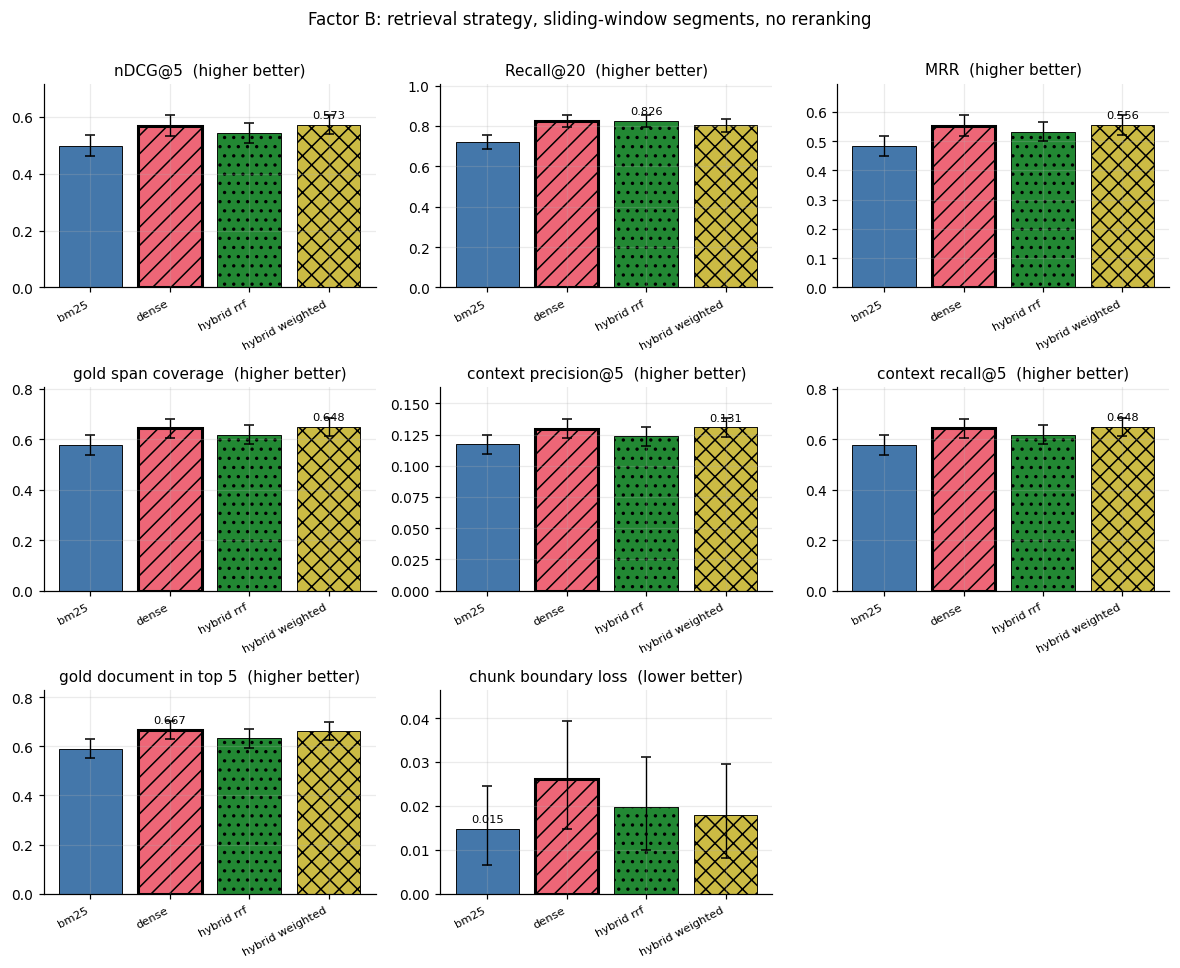

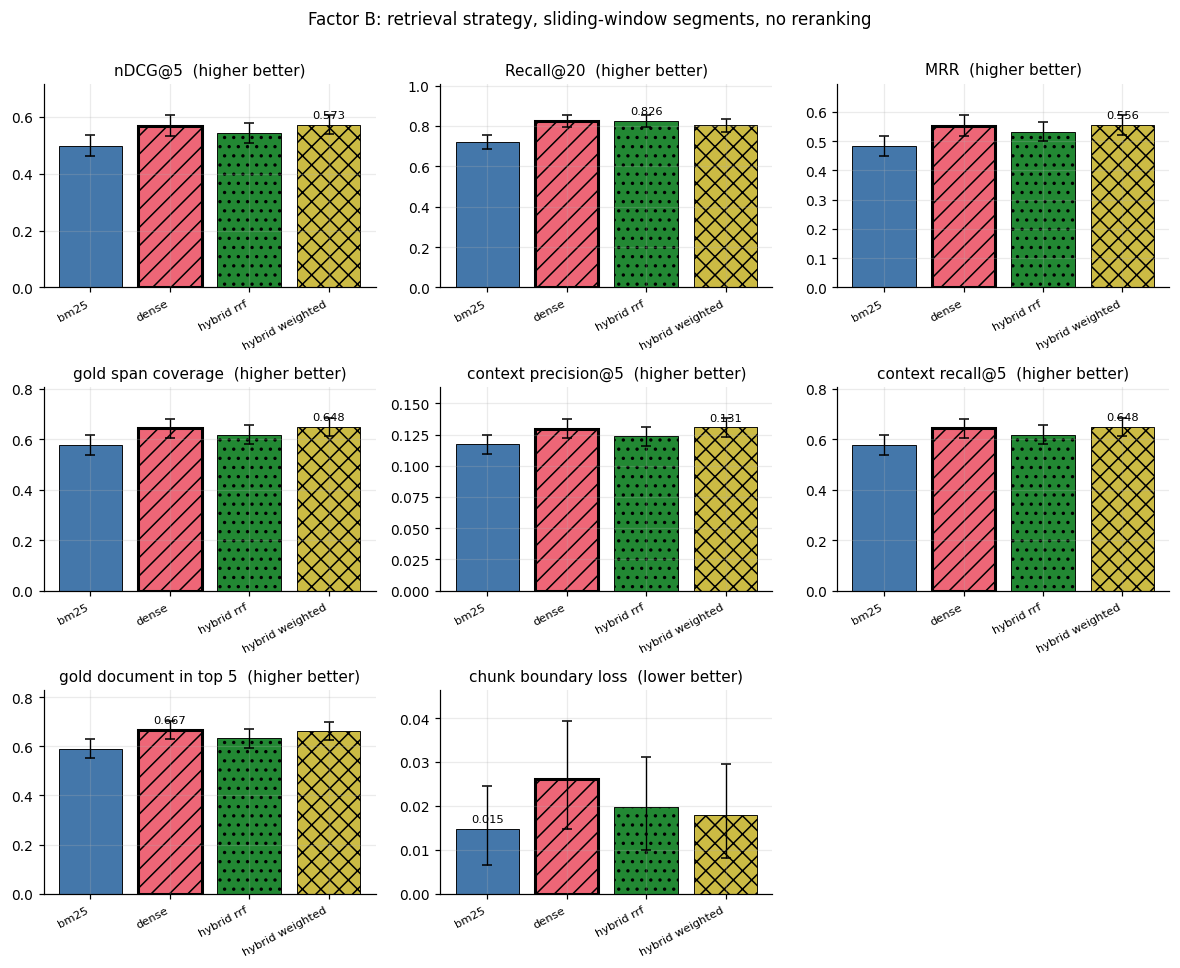

In [6]:
METRICS = C.RETRIEVAL_METRICS
summary_B = C.arm_summary(B, ['retriever'], METRICS)
summary_B['retriever'] = pd.Categorical(summary_B['retriever'],
                                        categories=C.CFG.RETRIEVERS, ordered=True)
summary_B = summary_B.sort_values('retriever')
display(summary_B[['retriever', 'n'] + METRICS].round(4))
C.save_table(summary_B, 'rq1_factorB_summary')
C.plot_metric_bars(summary_B, 'retriever', METRICS,
    'Factor B: retrieval strategy, sliding-window segments, no reranking',
    'fig_rq1_factorB_profile', baseline=C.CFG.BASELINE_RETRIEVER,
    caption='Retrieval-evidence profile of four retrieval strategies over all 610 answerable '
            'TechQA questions at 512-unit sliding-window segmentation without reranking. '
            'Error bars are 95% bootstrap intervals over questions.')

## 4. Contrasts against dense retrieval

,level,level_mean,baseline_mean,mean_diff,lo,hi,p_holm,significant,n
0,bm25,0.4987,0.5693,-0.0706,-0.1046,-0.0355,0.0000,True,610
1,hybrid_rrf,0.5429,0.5693,-0.0264,-0.0528,-0.0005,0.0936,False,610
2,hybrid_weighted,0.5726,0.5693,0.0033,-0.0226,0.0287,0.7948,False,610


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_contrasts.csv
  figure -> /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/figures/fig_rq1_factorB_forest.png

bm25 against dense gives a mean difference of -0.0706 in nDCG@5, with a 95% interval from -0.1046 to -0.0355 over 610 paired questions. The interval excludes zero.

hybrid rrf against dense gives a mean difference of -0.0264 in nDCG@5, with a 95% interval from -0.0528 to -0.0005 over 610 paired questions. The interval excludes zero.

hybrid weighted against dense gives a mean difference of +0.0033 in nDCG@5, with a 95% interval from -0.0226 to +0.0287 over 610 paired questions. The interval includes zero, so the difference is not resolved at this sample size.


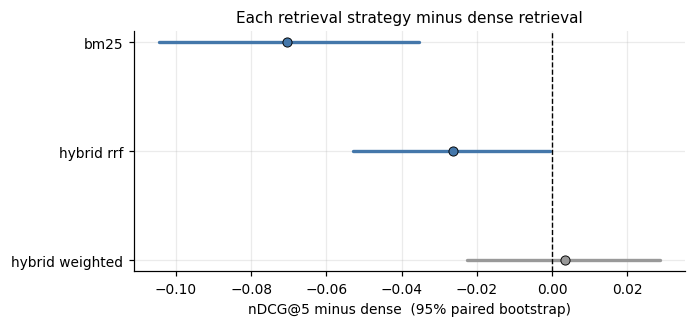

In [7]:
contrasts_B = C.pairwise_against_baseline(B, 'retriever', C.CFG.BASELINE_RETRIEVER, METRICS)
display(contrasts_B[contrasts_B.metric == 'nDCG@5'][
    ['level', 'level_mean', 'baseline_mean', 'mean_diff', 'lo', 'hi', 'p_holm',
     'significant', 'n']].round(4))
C.save_table(contrasts_B, 'rq1_factorB_contrasts')
C.plot_forest(contrasts_B, 'nDCG@5', 'Each retrieval strategy minus dense retrieval',
    'fig_rq1_factorB_forest',
    caption='Paired bootstrap 95% intervals for nDCG@5 of each retrieval strategy minus dense '
            'retrieval. Grey intervals cross zero.')
for _, r in contrasts_B[contrasts_B.metric == 'nDCG@5'].iterrows():
    print('\n' + C.describe_contrast(r))

## 5. Where the strategies disagree

The vocabulary-mismatch argument of Section 2.4 predicts that BM25 and dense retrieval fail on *different* questions. If that holds, the ceiling for fusion is higher than either alone, and the gap between the fusion result and that ceiling measures how much the fusion rule is leaving on the table.

In [8]:
w = C.to_wide(B, 'gold_document_in_top_5', 'retriever')
both = float(((w.bm25 > 0) & (w.dense > 0)).mean())
only_b = float(((w.bm25 > 0) & (w.dense == 0)).mean())
only_d = float(((w.bm25 == 0) & (w.dense > 0)).mean())
neither = float(((w.bm25 == 0) & (w.dense == 0)).mean())
oracle = both + only_b + only_d
fused = float((w['hybrid_rrf'] > 0).mean())
overlap = {'both_succeed': both, 'bm25_only': only_b, 'dense_only': only_d,
           'neither': neither, 'union_ceiling': oracle, 'hybrid_rrf_achieved': fused,
           'headroom_left_by_fusion': oracle - fused, 'n_questions': int(len(w))}
print(json.dumps(overlap, indent=1))
C.save_results(overlap, 'rq1_factorB_complementarity')

{
 "both_succeed": 0.5065573770491804,
 "bm25_only": 0.08360655737704918,
 "dense_only": 0.16065573770491803,
 "neither": 0.24918032786885247,
 "union_ceiling": 0.7508196721311475,
 "hybrid_rrf_achieved": 0.6327868852459017,
 "headroom_left_by_fusion": 0.11803278688524588,
 "n_questions": 610
}
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_complementarity.json


PosixPath('/content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_complementarity.json')

## 6. Cost, and what factor B contributes to RQ1

In [9]:
display(cost_B.round(2))
C.save_table(cost_B, 'rq1_factorB_cost')
eff_B = C.repeated_measures_effect(C.to_wide(B, 'nDCG@5', 'retriever'))
C.save_results({'effect_nDCG@5': eff_B, 'summary': summary_B.to_dict(orient='records'),
                'complementarity': overlap,
                'provenance': C.stamp({'factor': 'retrieval_strategy'})}, 'rq1_factorB')
print(f"Retrieval strategy, nDCG@5: levels span {eff_B['range']:.4f} "
      f"(95% CI {eff_B['range_lo']:.4f} to {eff_B['range_hi']:.4f}), "
      f"partial eta-squared {eff_B['eta2_partial']:.4f}, best level {eff_B['best_level']}.")
print('\nFactor B complete. Run RQ1_C_Reranking.ipynb next.')

,retriever,retrieval_ms,whole_matrix_s,index_mb
0,bm25,0.95,1.47,48.11
1,dense,0.04,0.09,55.73
2,hybrid_rrf,1.02,1.59,48.11
3,hybrid_weighted,1.05,1.65,48.11


  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB_cost.csv
  saved /content/drive/MyDrive/techqa_rq1/outputs_u512_o10_p0/rq1_factorB.json
Retrieval strategy, nDCG@5: levels span 0.0739 (95% CI 0.0539 to 0.1051), partial eta-squared 0.0245, best level hybrid_weighted.

Factor B complete. Run RQ1_C_Reranking.ipynb next.
